Shapes: 
  races       : (1125, 18) 
  results     : (26759, 18) 
  pitstops   : (11371, 7) 
  laptimes   : (589081, 6) 
  circuits   : (77, 9) 
  drivers    : (861, 9) 
  constructors: (212, 5)

=== Training DELTA model ===
Epoch 01 | train_huber=7398777.5 | val_huber=9350305.7 | val_RMSE=55121.8 ms | val_MAE=5204.0 ms | lr=5.00e-04->5.00e-04
Epoch 02 | train_huber=7028740.5 | val_huber=8297471.8 | val_RMSE=50642.0 ms | val_MAE=4695.3 ms | lr=5.00e-04->5.00e-04
Epoch 03 | train_huber=5785770.5 | val_huber=5859597.0 | val_RMSE=41182.4 ms | val_MAE=3467.7 ms | lr=5.00e-04->5.00e-04
Epoch 04 | train_huber=4171376.5 | val_huber=4107661.7 | val_RMSE=37055.6 ms | val_MAE=2560.4 ms | lr=5.00e-04->5.00e-04
Epoch 05 | train_huber=3457939.8 | val_huber=3600193.5 | val_RMSE=34948.0 ms | val_MAE=2290.8 ms | lr=5.00e-04->5.00e-04
Epoch 06 | train_huber=3145274.1 | val_huber=3353918.1 | val_RMSE=32456.5 ms | val_MAE=2153.2 ms | lr=5.00e-04->5.00e-04
Epoch 07 | train_huber=2943071.2 | val_huber=3083

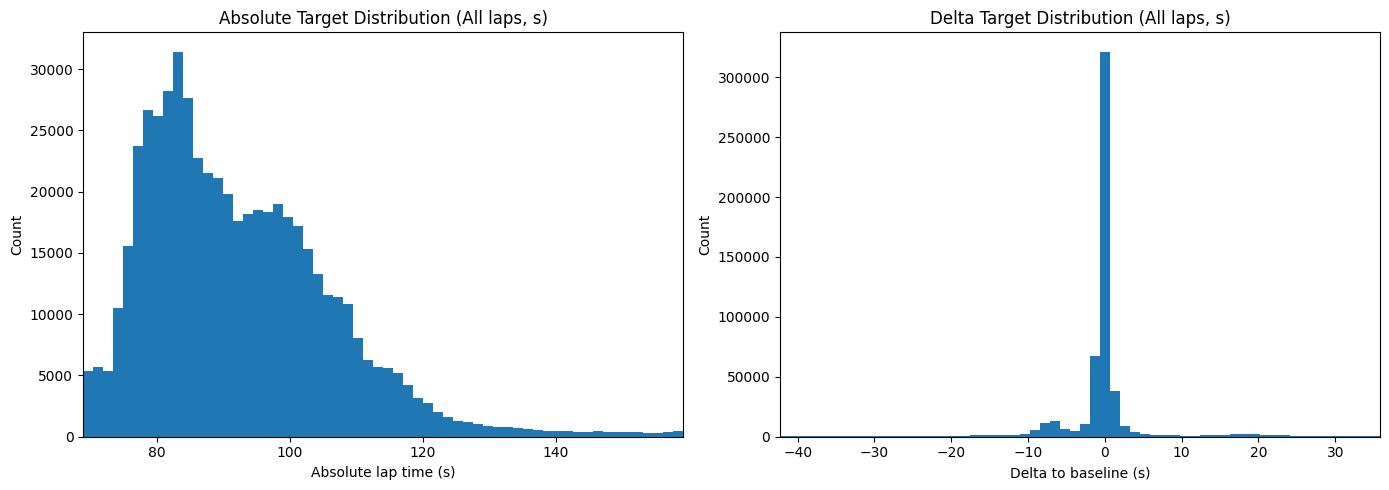

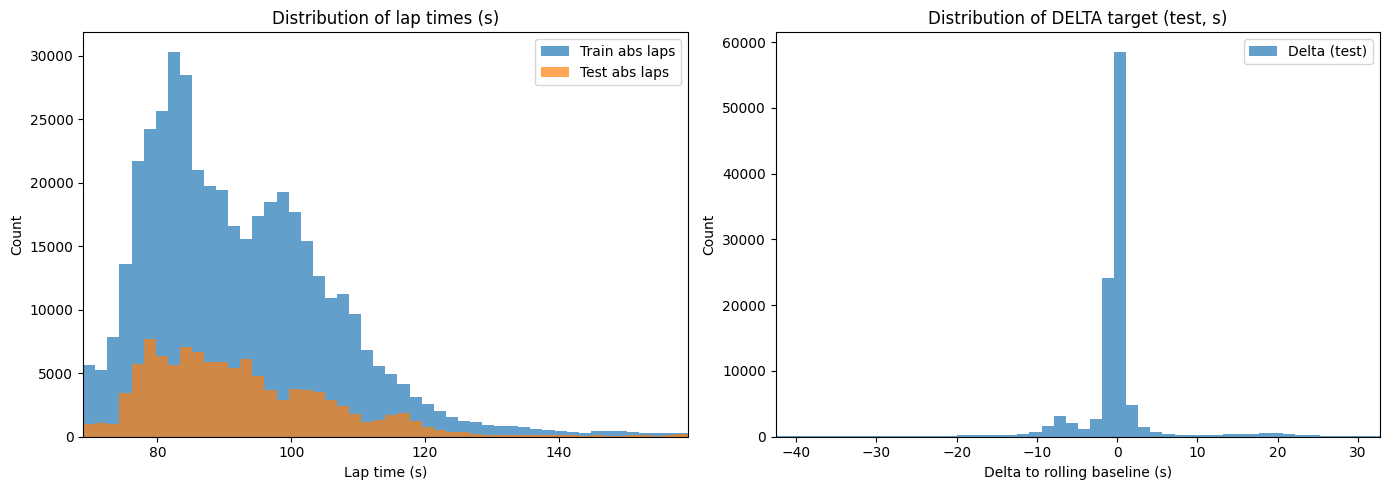

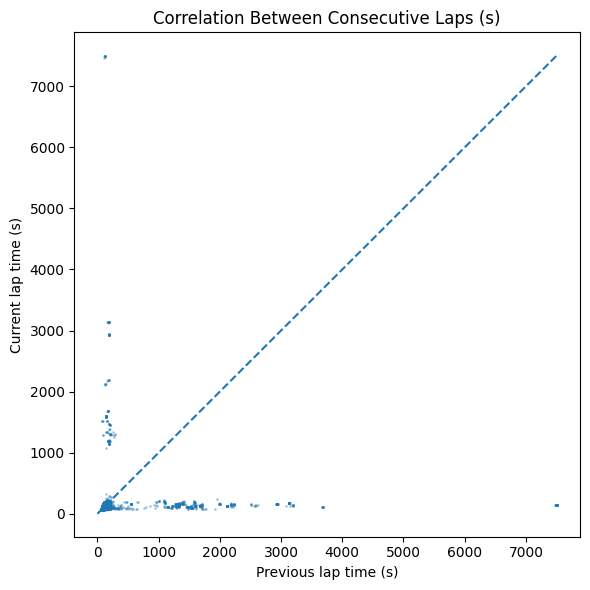

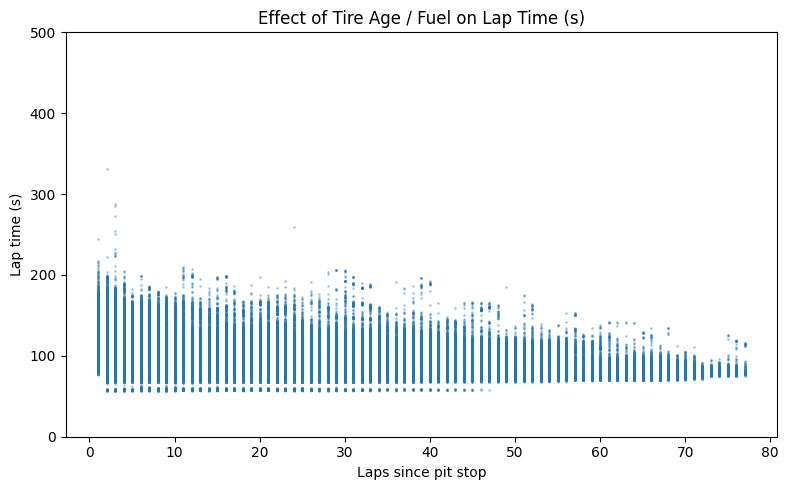

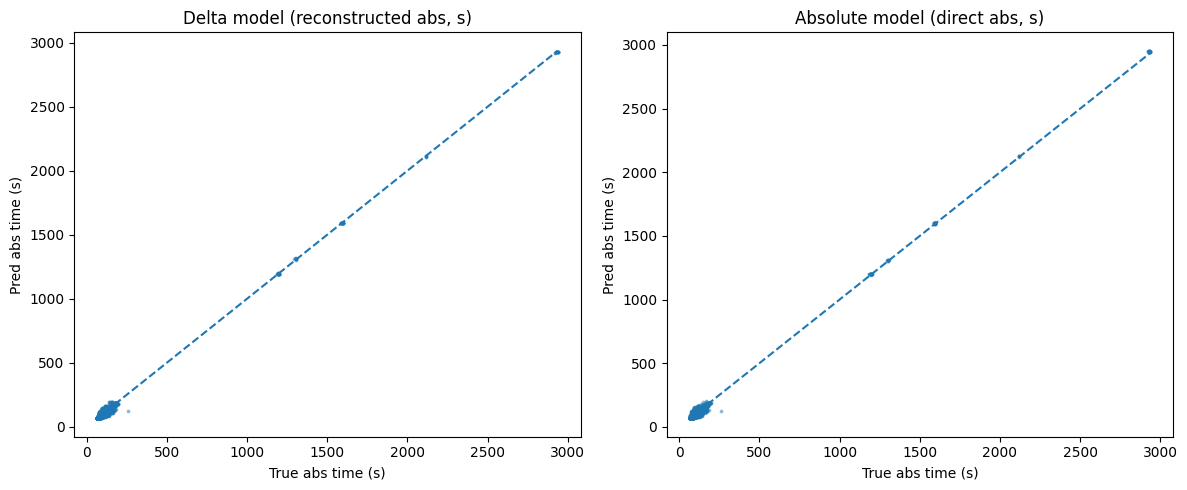

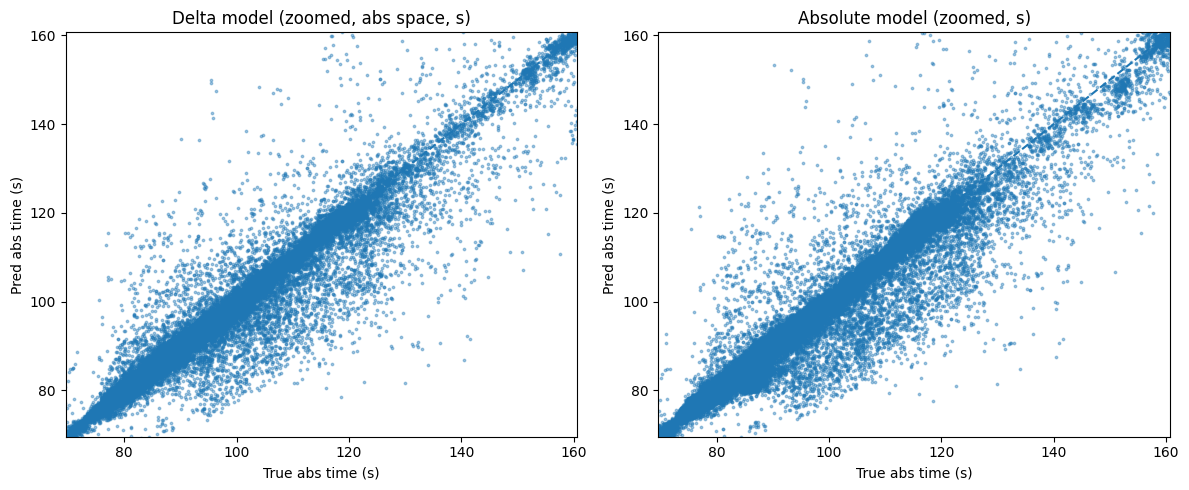

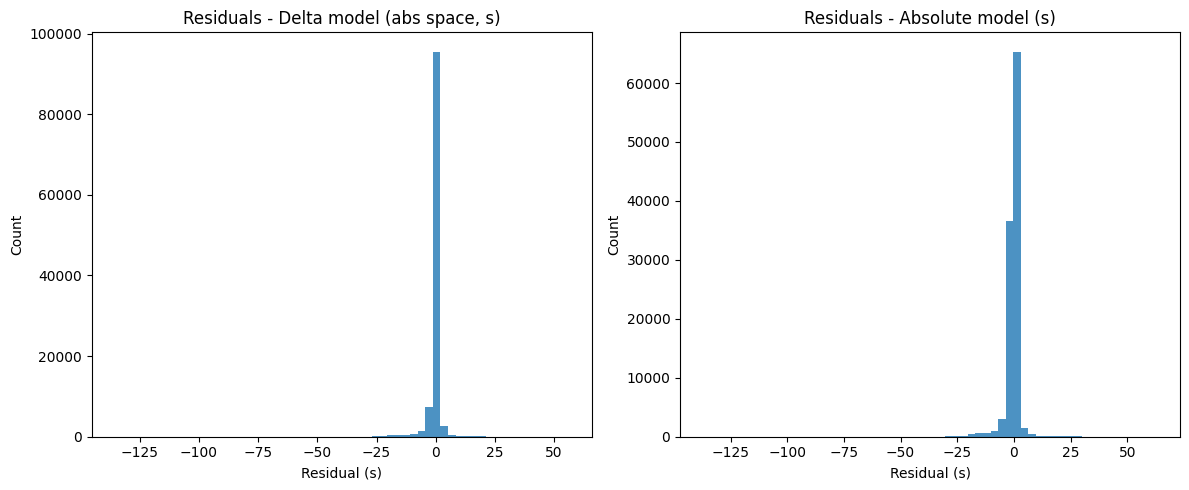

C:\Users\User\AppData\Local\Temp\ipykernel_17832\741457610.py:702: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([res_delta_s, res_abs_s], labels=["Delta->Abs", "Absolute"])


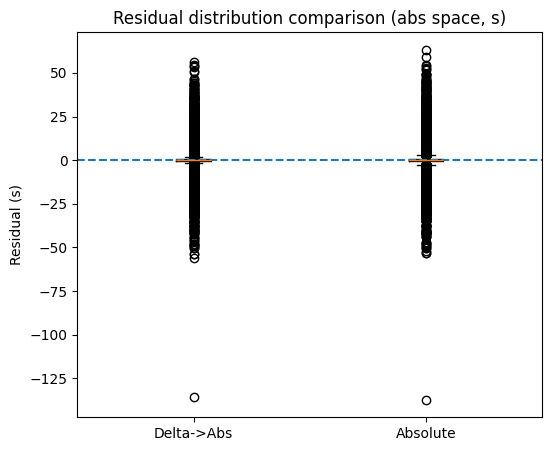

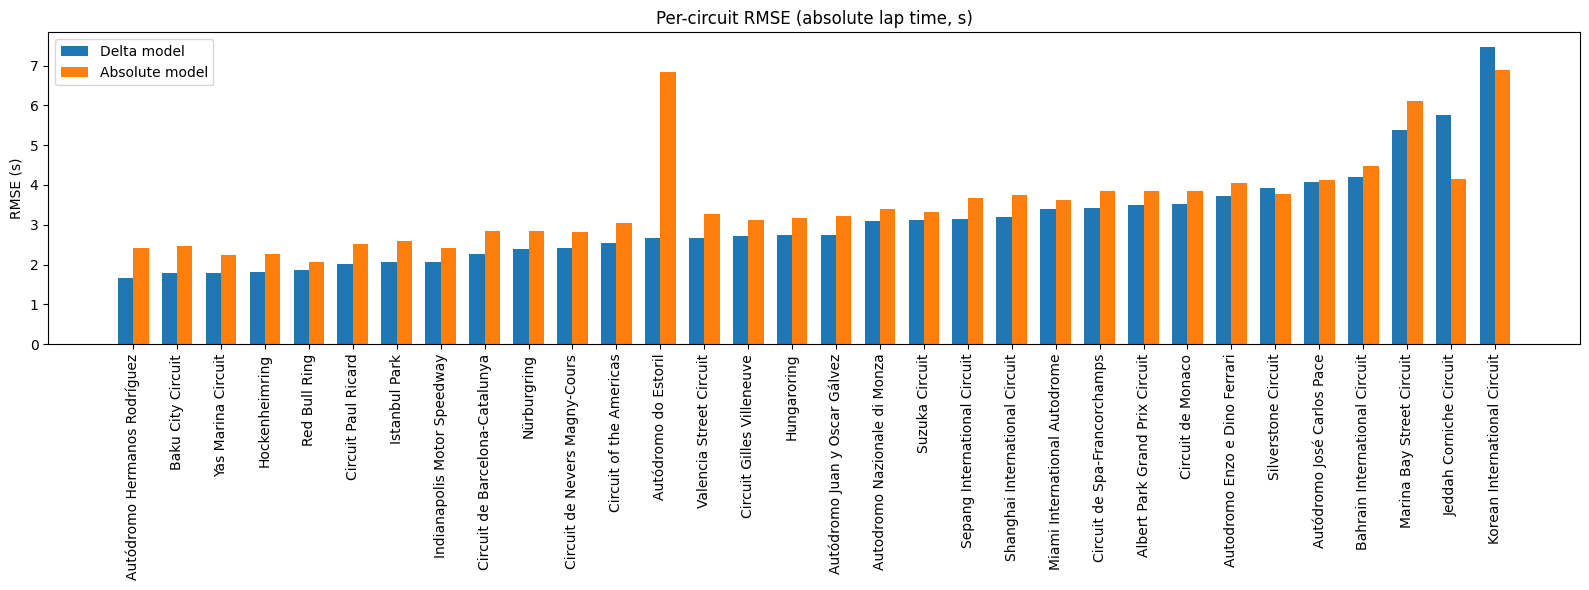

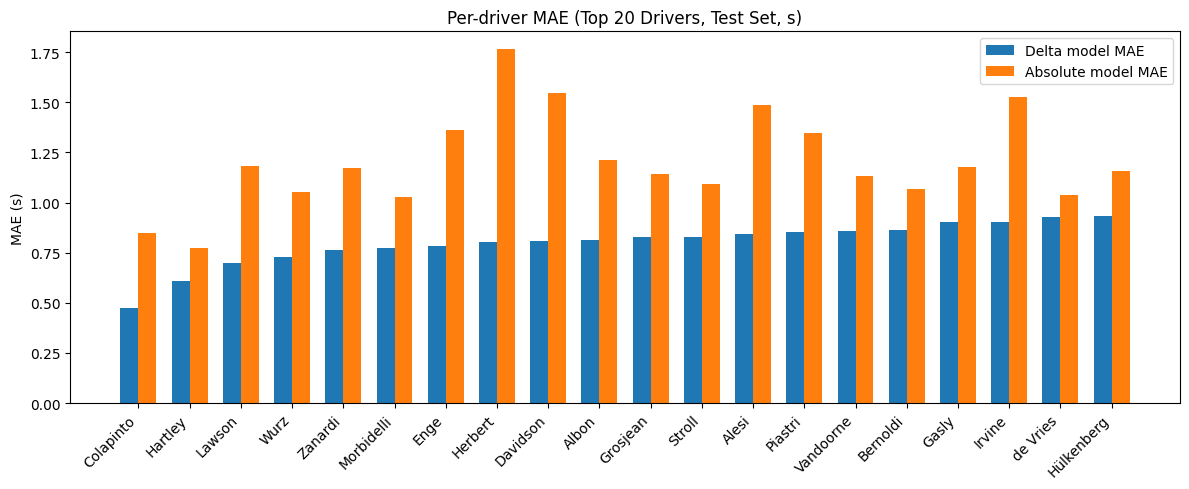

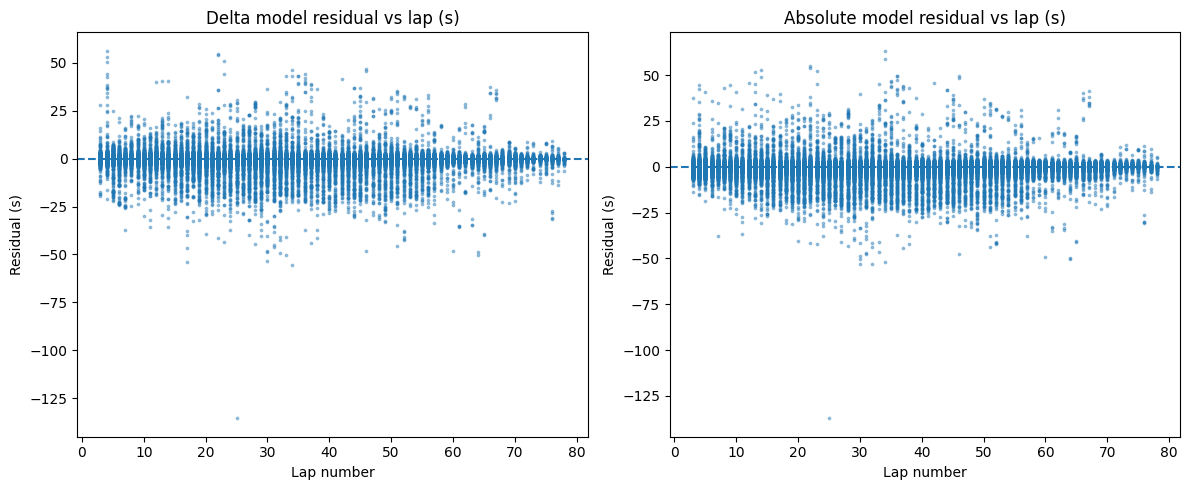

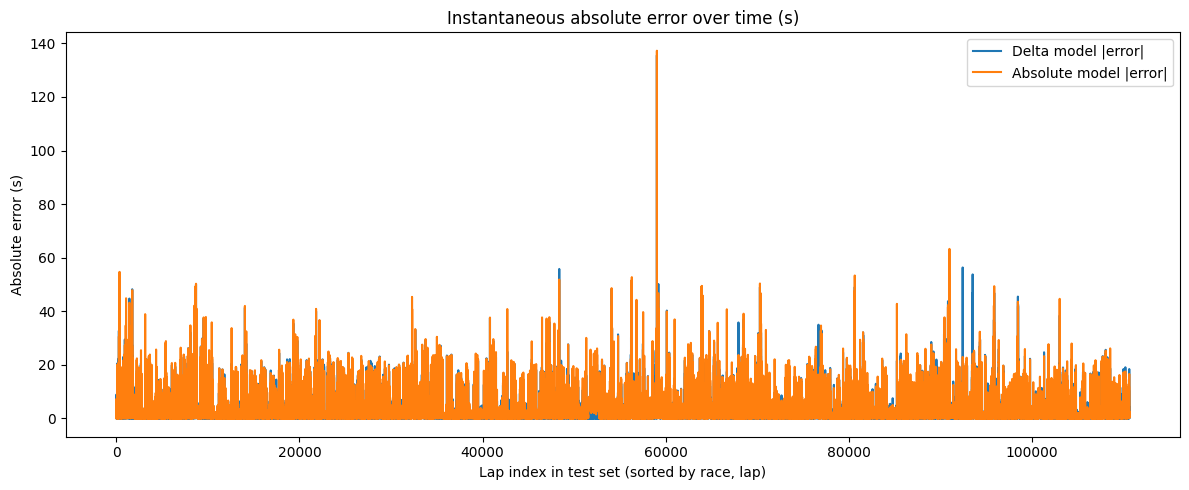

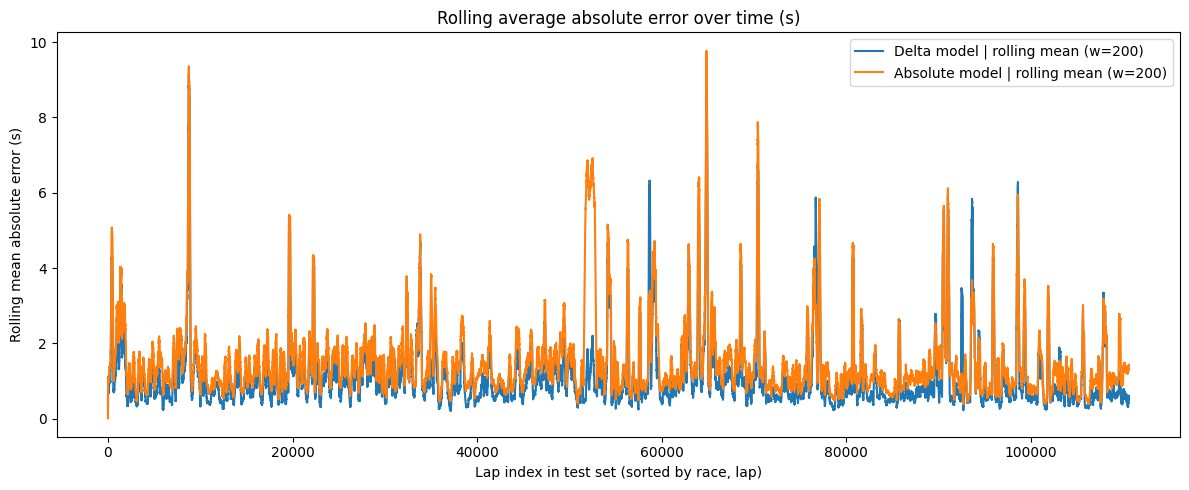

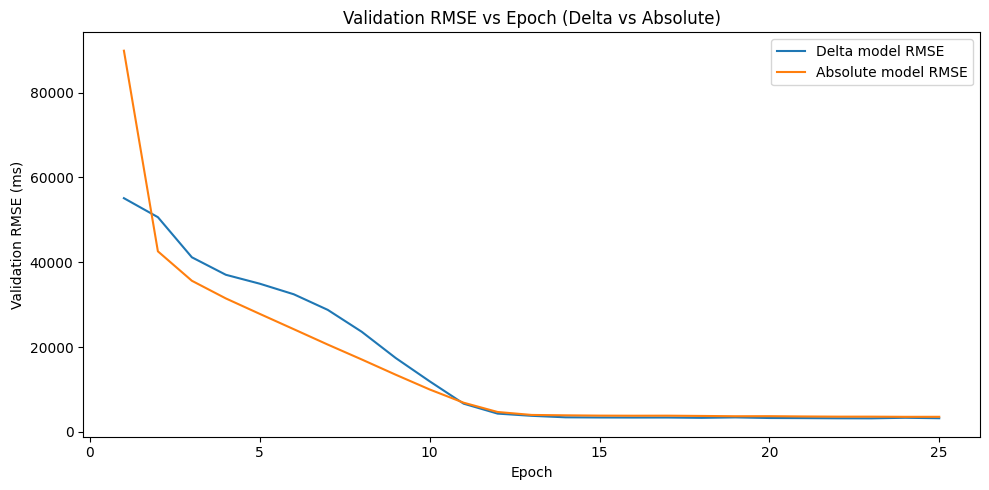

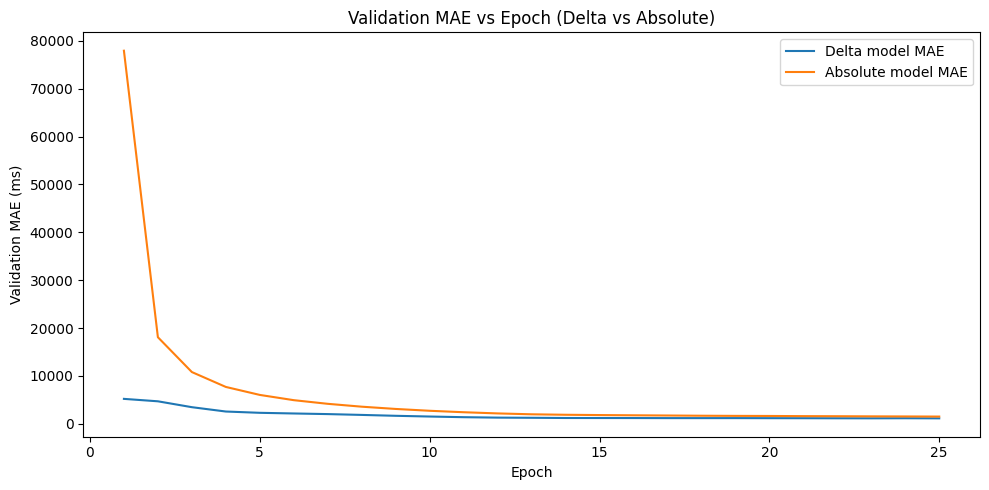

In [1]:
# ============================================
# F1 LAP TIME PREDICTION — DELTA vs ABSOLUTE
# - Same dataset & split
# - Model 1: predicts DELTA (lap_ms - rolling baseline)
# - Model 2: predicts ABSOLUTE lap time (no baseline feature)
# - Metrics: MAE + RMSE for both
# - Plots (most in SECONDS to avoid 1e6 axes):
#     * global target distributions (abs & delta)  [FIXED SCALE]
#     * distributions train/test                  [FIXED SCALE]
#     * correlation prev vs current lap
#     * effect of laps-since-pit
#     * true vs pred (both models)
#     * ZOOMED true vs pred (focus on blob)
#     * residual histograms + boxplots
#     * per-circuit RMSE
#     * per-driver MAE (top 20)
#     * residual vs lap
#     * error over time (instant + rolling)
#     * RMSE vs epoch, MAE vs epoch
# ============================================

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

# -----------------------------
# 1) Load CSVs
# -----------------------------
races        = pd.read_csv("races.csv")
results      = pd.read_csv("results.csv")
pitstops     = pd.read_csv("pit_stops.csv")
laptimes     = pd.read_csv("lap_times.csv")
circuits     = pd.read_csv("circuits.csv")
constructors = pd.read_csv("constructors.csv")
drivers      = pd.read_csv("drivers.csv")

print("Shapes:",
      "\n  races       :", races.shape,
      "\n  results     :", results.shape,
      "\n  pitstops   :", pitstops.shape,
      "\n  laptimes   :", laptimes.shape,
      "\n  circuits   :", circuits.shape,
      "\n  drivers    :", drivers.shape,
      "\n  constructors:", constructors.shape)

# -----------------------------
# 2) Basic checks & typing
# -----------------------------
for col in ["raceId", "driverId", "lap", "milliseconds", "position"]:
    if col not in laptimes.columns:
        raise ValueError(f"Expected column '{col}' in lap_times.csv")

laptimes["milliseconds"] = pd.to_numeric(laptimes["milliseconds"], errors="coerce")

# avoid collisions with results.position
laptimes = laptimes.rename(columns={"position": "lap_position"})
results  = results.rename(columns={"position": "finish_position"})

# keep unique (raceId, driverId) in results
if "positionOrder" in results.columns:
    results = results.sort_values(
        ["raceId", "driverId", "positionOrder"], na_position="last"
    )
results = results.drop_duplicates(subset=["raceId", "driverId"], keep="first")

# pit flags
if not pitstops.empty and "lap" in pitstops.columns:
    pit = pitstops.copy()
    pit["pit_flag"] = 1
    pit_map = pit[["raceId", "driverId", "lap", "pit_flag"]].drop_duplicates(
        ["raceId", "driverId", "lap"]
    )
else:
    pit_map = pd.DataFrame(columns=["raceId", "driverId", "lap", "pit_flag"])

# -----------------------------
# 3) Build base table (one time)
# -----------------------------
df = (
    laptimes
    .merge(
        races[["raceId", "year", "round", "circuitId"]],
        on="raceId", how="left"
    )
    .merge(
        circuits[["circuitId", "name", "lat", "lng", "alt"]],
        on="circuitId", how="left"
    )
    .merge(
        results[[
            "raceId", "driverId", "constructorId",
            "grid", "finish_position", "points"
        ]],
        on=["raceId", "driverId"], how="left"
    )
    .merge(
        drivers[["driverId", "surname"]],
        on="driverId", how="left"
    )
)

if not pit_map.empty:
    df = df.merge(pit_map, on=["raceId", "driverId", "lap"], how="left")

df["pit_flag"] = df["pit_flag"].fillna(0).astype(int)

# sort chronologically
df = df.sort_values(["raceId", "driverId", "lap"]).reset_index(drop=True)

# -----------------------------
# 4) Time-series features
# -----------------------------
grp = df.groupby(["raceId", "driverId"], sort=False)

df["prev_lap_ms"] = grp["milliseconds"].shift(1)
df["roll3_ms"]    = grp["milliseconds"].transform(
    lambda s: s.shift(1).rolling(3, min_periods=1).mean()
)

df["segment"] = grp["pit_flag"].cumsum()
df["laps_since_pit"] = df.groupby(
    ["raceId", "driverId", "segment"]
).cumcount()
df.drop(columns=["segment"], inplace=True)

# drop first laps (no prev)
df = df[~df["prev_lap_ms"].isna()].copy()

# -----------------------------
# 5) Filter to non-pit, de-outlier
# -----------------------------
df = df[df["pit_flag"] == 0].copy()

g = df.groupby("raceId")["milliseconds"]
low  = g.transform(lambda s: s.quantile(0.01))
high = g.transform(lambda s: s.quantile(0.99))
df = df[(df["milliseconds"] >= low) & (df["milliseconds"] <= high)].copy()

# recompute groupby
grp = df.groupby(["raceId", "driverId"], sort=False)

# -----------------------------
# 6) Baseline and two targets
# -----------------------------
df["baseline_ms"] = grp["milliseconds"].transform(
    lambda s: s.shift(1).rolling(3, min_periods=1).mean()
)
df = df[df["baseline_ms"].notna()].copy()

# targets
y_delta = (df["milliseconds"] - df["baseline_ms"]).astype("float32").values
y_abs   = df["milliseconds"].astype("float32").values

# -----------------------------
# 7) Features (shared core)
# -----------------------------
numeric_common = [
    "year", "round", "lap", "grid",
    "prev_lap_ms", "roll3_ms",
    "pit_flag", "laps_since_pit",
    "lat", "lng", "alt",
]

# race/lap medians + position dynamics
df["race_med_ms"] = df.groupby("raceId")["milliseconds"].transform("median")
df["lap_med_ms"]  = df.groupby(["raceId", "lap"])["milliseconds"].transform("median")
df["prev_pos"]    = grp["lap_position"].shift(1)
df["pos_change"]  = df["prev_pos"].fillna(df["lap_position"]) - df["lap_position"]

numeric_common += [
    "race_med_ms", "lap_med_ms",
    "lap_position", "prev_pos", "pos_change"
]

# numeric; fill NA
for c in numeric_common + ["baseline_ms"]:
    if c not in df.columns:
        df[c] = np.nan

df[numeric_common + ["baseline_ms"]] = df[
    numeric_common + ["baseline_ms"]
].fillna(df[numeric_common + ["baseline_ms"]].median(numeric_only=True))

# model-specific numeric feature sets:
numeric_cols_delta = numeric_common + ["baseline_ms"]  # delta model uses baseline
numeric_cols_abs   = numeric_common.copy()             # abs model does not

# categorical
cat_cols = ["driverId", "constructorId", "circuitId"]

# -----------------------------
# 8) Categoricals → indices
# -----------------------------
def build_id_map(series):
    uniq = pd.Series(series.dropna().unique())
    if np.issubdtype(uniq.dtype, np.number):
        uniq = uniq.astype(int)
    return {int(v): i + 1 for i, v in enumerate(sorted(uniq))}

driver_map  = build_id_map(df["driverId"])
cons_map    = build_id_map(df["constructorId"])
circuit_map = build_id_map(df["circuitId"])

def map_with_unk(series, mp):
    return series.apply(lambda v: mp.get(int(v), 0)).astype("int64")

X_driver = map_with_unk(df["driverId"],      driver_map).to_numpy()
X_cons   = map_with_unk(df["constructorId"], cons_map).to_numpy()
X_circ   = map_with_unk(df["circuitId"],     circuit_map).to_numpy()

X_num_delta = df[numeric_cols_delta].astype("float32").values
X_num_abs   = df[numeric_cols_abs].astype("float32").values

n_driver = len(driver_map)  + 1
n_cons   = len(cons_map)    + 1
n_circ   = len(circuit_map) + 1

# -----------------------------
# 9) Train/val split (same for both models)
# -----------------------------
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df["raceId"].values))

# delta model arrays
Xd_num_tr, Xd_num_te = X_num_delta[train_idx], X_num_delta[test_idx]
Xd_drv_tr, Xd_drv_te = X_driver[train_idx],    X_driver[test_idx]
Xd_con_tr, Xd_con_te = X_cons[train_idx],      X_cons[test_idx]
Xd_cir_tr, Xd_cir_te = X_circ[train_idx],      X_circ[test_idx]
yd_tr,    yd_te      = y_delta[train_idx],     y_delta[test_idx]

# absolute model arrays
Xa_num_tr, Xa_num_te = X_num_abs[train_idx], X_num_abs[test_idx]
Xa_drv_tr, Xa_drv_te = X_driver[train_idx],  X_driver[test_idx]
Xa_con_tr, Xa_con_te = X_cons[train_idx],    X_cons[test_idx]
Xa_cir_tr, Xa_cir_te = X_circ[train_idx],    X_circ[test_idx]
ya_tr,    ya_te      = y_abs[train_idx],     y_abs[test_idx]

# scalers
scaler_delta = StandardScaler()
Xd_num_tr = scaler_delta.fit_transform(Xd_num_tr)
Xd_num_te = scaler_delta.transform(Xd_num_te)

scaler_abs = StandardScaler()
Xa_num_tr = scaler_abs.fit_transform(Xa_num_tr)
Xa_num_te = scaler_abs.transform(Xa_num_te)

# baseline for reconstruction (delta model -> abs)
baseline_te = df["baseline_ms"].iloc[test_idx].to_numpy().astype("float32")

# -----------------------------
# 10) Dataset / loaders
# -----------------------------
class LapDataset(Dataset):
    def __init__(self, Xnum, Xdrv, Xcon, Xcir, y=None):
        self.Xnum = torch.tensor(Xnum, dtype=torch.float32)
        self.Xdrv = torch.tensor(Xdrv, dtype=torch.long)
        self.Xcon = torch.tensor(Xcon, dtype=torch.long)
        self.Xcir = torch.tensor(Xcir, dtype=torch.long)
        self.y    = None if y is None else torch.tensor(
            y, dtype=torch.float32
        ).view(-1, 1)

    def __len__(self):
        return self.Xnum.shape[0]

    def __getitem__(self, i):
        if self.y is None:
            return (self.Xnum[i], self.Xdrv[i], self.Xcon[i], self.Xcir[i])
        return (self.Xnum[i], self.Xdrv[i], self.Xcon[i], self.Xcir[i], self.y[i])

batch_train = 2048
batch_val   = 4096

train_loader_delta = DataLoader(
    LapDataset(Xd_num_tr, Xd_drv_tr, Xd_con_tr, Xd_cir_tr, yd_tr),
    batch_size=batch_train, shuffle=True
)
val_loader_delta = DataLoader(
    LapDataset(Xd_num_te, Xd_drv_te, Xd_con_te, Xd_cir_te, yd_te),
    batch_size=batch_val, shuffle=False
)

train_loader_abs = DataLoader(
    LapDataset(Xa_num_tr, Xa_drv_tr, Xa_con_tr, Xa_cir_tr, ya_tr),
    batch_size=batch_train, shuffle=True
)
val_loader_abs = DataLoader(
    LapDataset(Xa_num_te, Xa_drv_te, Xa_con_te, Xa_cir_te, ya_te),
    batch_size=batch_val, shuffle=False
)

# -----------------------------
# 11) Model definition
# -----------------------------
def emb_dim(n):
    return int(min(48, max(4, round(math.sqrt(n)))))


class LapNet(nn.Module):
    def __init__(self, n_num_features, n_driver, n_cons, n_circ):
        super().__init__()
        self.emb_driver = nn.Embedding(n_driver, emb_dim(n_driver))
        self.emb_cons   = nn.Embedding(n_cons,   emb_dim(n_cons))
        self.emb_circ   = nn.Embedding(n_circ,   emb_dim(n_circ))

        in_dim = (
            n_num_features
            + emb_dim(n_driver)
            + emb_dim(n_cons)
            + emb_dim(n_circ)
        )

        self.mlp = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

        for m in self.mlp:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                nn.init.zeros_(m.bias)

    def forward(self, xnum, xdrv, xcon, xcir):
        x = torch.cat(
            [
                xnum,
                self.emb_driver(xdrv),
                self.emb_cons(xcon),
                self.emb_circ(xcir),
            ],
            dim=1,
        )
        return self.mlp(x)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_delta = LapNet(Xd_num_tr.shape[1], n_driver, n_cons, n_circ).to(device)
model_abs   = LapNet(Xa_num_tr.shape[1], n_driver, n_cons, n_circ).to(device)

# -----------------------------
# 12) Training function (Huber + RMSE + MAE history)
# -----------------------------
def train_model(model, train_loader, val_loader, n_epochs=25, patience=8):
    optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-6)
    criterion = torch.nn.HuberLoss(delta=2000.0)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=2
    )

    def eval_loader(loader):
        model.eval()
        total_loss, total_sq_err, total_abs_err, n = 0.0, 0.0, 0.0, 0
        with torch.no_grad():
            for xb_num, xb_drv, xb_con, xb_cir, yb in loader:
                xb_num = xb_num.to(device)
                xb_drv = xb_drv.to(device)
                xb_con = xb_con.to(device)
                xb_cir = xb_cir.to(device)
                yb     = yb.to(device)

                pred = model(xb_num, xb_drv, xb_con, xb_cir)
                loss = criterion(pred, yb)

                total_loss    += loss.item() * yb.size(0)
                total_sq_err  += ((pred - yb) ** 2).sum().item()
                total_abs_err += (pred - yb).abs().sum().item()
                n             += yb.size(0)
        avg_loss = total_loss / n
        rmse_val = math.sqrt(total_sq_err / n)
        mae_val  = total_abs_err / n
        return avg_loss, rmse_val, mae_val

    best_rmse = float("inf")
    best_state = None
    stale = 0

    train_loss_hist = []
    val_rmse_hist   = []
    val_mae_hist    = []

    for ep in range(1, n_epochs + 1):
        model.train()
        running_loss, seen = 0.0, 0

        for xb_num, xb_drv, xb_con, xb_cir, yb in train_loader:
            xb_num = xb_num.to(device)
            xb_drv = xb_drv.to(device)
            xb_con = xb_con.to(device)
            xb_cir = xb_cir.to(device)
            yb     = yb.to(device)

            optimizer.zero_grad()
            pred = model(xb_num, xb_drv, xb_con, xb_cir)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * yb.size(0)
            seen         += yb.size(0)

        train_loss = running_loss / seen
        val_loss, val_rmse, val_mae = eval_loader(val_loader)

        train_loss_hist.append(train_loss)
        val_rmse_hist.append(val_rmse)
        val_mae_hist.append(val_mae)

        old_lr = optimizer.param_groups[0]["lr"]
        scheduler.step(val_loss)
        new_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {ep:02d} | train_huber={train_loss:.1f} "
            f"| val_huber={val_loss:.1f} | val_RMSE={val_rmse:.1f} ms "
            f"| val_MAE={val_mae:.1f} ms | lr={old_lr:.2e}->{new_lr:.2e}"
        )

        if val_rmse + 1e-3 < best_rmse:
            best_rmse = val_rmse
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}
            stale = 0
        else:
            stale += 1
            if stale >= patience:
                print("Early stopping.")
                break

    model.load_state_dict(best_state)
    history = {
        "train_loss": train_loss_hist,
        "val_rmse": val_rmse_hist,
        "val_mae": val_mae_hist,
    }
    return best_rmse, history

# -----------------------------
# 13) Train both models
# -----------------------------
print("\n=== Training DELTA model ===")
best_rmse_delta, hist_delta = train_model(
    model_delta, train_loader_delta, val_loader_delta
)

print("\n=== Training ABSOLUTE model ===")
best_rmse_abs, hist_abs = train_model(
    model_abs, train_loader_abs, val_loader_abs
)

# -----------------------------
# 14) Predictions on test set
# -----------------------------
def predict_all(model, loader):
    model.eval()
    preds = []
    with torch.no_grad():
        for xb_num, xb_drv, xb_con, xb_cir, _ in loader:
            xb_num = xb_num.to(device)
            xb_drv = xb_drv.to(device)
            xb_con = xb_con.to(device)
            xb_cir = xb_cir.to(device)
            p = model(xb_num, xb_drv, xb_con, xb_cir).squeeze(1).cpu().numpy()
            preds.append(p)
    return np.concatenate(preds, axis=0)

y_pred_delta_test = predict_all(model_delta, val_loader_delta)
y_true_delta_test = yd_te

y_pred_abs_test = predict_all(model_abs, val_loader_abs)
y_true_abs_test = ya_te

# delta model: reconstruct absolute laps
abs_pred_from_delta = baseline_te + y_pred_delta_test
abs_true_from_delta = baseline_te + y_true_delta_test

# -----------------------------
# 15) Metrics: MAE + RMSE for both
# -----------------------------
def mae(x, y): return float(np.mean(np.abs(x - y)))
def rmse(x, y): return float(math.sqrt(np.mean((x - y) ** 2)))

mae_delta   = mae(y_true_delta_test, y_pred_delta_test)
rmse_delta  = rmse(y_true_delta_test, y_pred_delta_test)
mae_abs_d   = mae(abs_true_from_delta, abs_pred_from_delta)
rmse_abs_d  = rmse(abs_true_from_delta, abs_pred_from_delta)

mae_abs_a  = mae(y_true_abs_test, y_pred_abs_test)
rmse_abs_a = rmse(y_true_abs_test, y_pred_abs_test)

print("\n=== METRICS (TEST SET) ===")
print(f"DELTA model - delta space:    MAE={mae_delta:.1f} ms, RMSE={rmse_delta:.1f} ms")
print(f"DELTA model - absolute space: MAE={mae_abs_d:.1f} ms, RMSE={rmse_abs_d:.1f} ms")
print(f"ABSOLUTE model:               MAE={mae_abs_a:.1f} ms, RMSE={rmse_abs_a:.1f} ms")

# -----------------------------
# 16) Build a test DataFrame for plotting
# -----------------------------
test_df = df.iloc[test_idx].copy()
test_df["true_abs_deltaModel"] = abs_true_from_delta
test_df["pred_abs_deltaModel"] = abs_pred_from_delta
test_df["err_abs_deltaModel"]  = abs_pred_from_delta - abs_true_from_delta

test_df["true_abs_absModel"] = y_true_abs_test
test_df["pred_abs_absModel"] = y_pred_abs_test
test_df["err_abs_absModel"]  = y_pred_abs_test - y_true_abs_test

# ============================================
# PLOTTING SECTION  (many plots, mostly in SECONDS)
# ============================================

# -----------------------------
# A) Global target distributions (all laps) in seconds
#     -> zoomed using robust percentiles
# -----------------------------
abs_all_s   = df["milliseconds"].values / 1000.0
delta_all_s = (df["milliseconds"].values - df["baseline_ms"].values) / 1000.0

abs_lo,   abs_hi   = np.percentile(abs_all_s,   [0.5, 99.5])
delta_lo, delta_hi = np.percentile(delta_all_s, [0.5, 99.5])

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(abs_all_s, bins=60, range=(abs_lo, abs_hi))
plt.xlabel("Absolute lap time (s)")
plt.ylabel("Count")
plt.title("Absolute Target Distribution (All laps, s)")
plt.xlim(abs_lo, abs_hi)

plt.subplot(1, 2, 2)
plt.hist(delta_all_s, bins=60, range=(delta_lo, delta_hi))
plt.xlabel("Delta to baseline (s)")
plt.ylabel("Count")
plt.title("Delta Target Distribution (All laps, s)")
plt.xlim(delta_lo, delta_hi)

plt.tight_layout()
plt.show()

# -----------------------------
# B) Distributions train/test abs & delta (seconds)
#     -> zoomed using robust percentiles
# -----------------------------
lap_train_s = ya_tr / 1000.0
lap_test_s  = y_true_abs_test / 1000.0
delta_test_s = y_true_delta_test / 1000.0

abs_combined = np.concatenate([lap_train_s, lap_test_s])
abs_lo, abs_hi = np.percentile(abs_combined, [0.5, 99.5])
delta_lo, delta_hi = np.percentile(delta_test_s, [0.5, 99.5])

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(lap_train_s, bins=50, alpha=0.7, label="Train abs laps",
         range=(abs_lo, abs_hi))
plt.hist(lap_test_s,  bins=50, alpha=0.7, label="Test abs laps",
         range=(abs_lo, abs_hi))
plt.xlabel("Lap time (s)")
plt.ylabel("Count")
plt.title("Distribution of lap times (s)")
plt.xlim(abs_lo, abs_hi)
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(delta_test_s, bins=50, alpha=0.7, label="Delta (test)",
         range=(delta_lo, delta_hi))
plt.xlabel("Delta to rolling baseline (s)")
plt.ylabel("Count")
plt.title("Distribution of DELTA target (test, s)")
plt.xlim(delta_lo, delta_hi)
plt.legend()

plt.tight_layout()
plt.show()

# -----------------------------
# C) Correlation prev vs current lap (seconds)
# -----------------------------
plt.figure(figsize=(6, 6))
plt.scatter(df["prev_lap_ms"] / 1000.0, df["milliseconds"] / 1000.0,
            s=1, alpha=0.3)
mx = max(df["prev_lap_ms"].max(), df["milliseconds"].max()) / 1000.0
plt.plot([0, mx], [0, mx], '--')
plt.xlabel("Previous lap time (s)")
plt.ylabel("Current lap time (s)")
plt.title("Correlation Between Consecutive Laps (s)")
plt.tight_layout()
plt.show()

# -----------------------------
# D) Effect of laps since pit (seconds)
# -----------------------------
plt.figure(figsize=(8, 5))
plt.scatter(df["laps_since_pit"], df["milliseconds"] / 1000.0,
            s=1, alpha=0.3)
plt.xlabel("Laps since pit stop")
plt.ylabel("Lap time (s)")
plt.title("Effect of Tire Age / Fuel on Lap Time (s)")
plt.ylim(0, 500)
plt.tight_layout()
plt.show()

# -----------------------------
# E) True vs predicted absolute (both models) in seconds
# -----------------------------
true_delta_abs_s = abs_true_from_delta / 1000.0
pred_delta_abs_s = abs_pred_from_delta / 1000.0
true_abs_s       = y_true_abs_test / 1000.0
pred_abs_s       = y_pred_abs_test / 1000.0

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(true_delta_abs_s, pred_delta_abs_s, s=3, alpha=0.4)
diag = np.linspace(true_delta_abs_s.min(), true_delta_abs_s.max(), 100)
plt.plot(diag, diag, linestyle="--")
plt.xlabel("True abs time (s)")
plt.ylabel("Pred abs time (s)")
plt.title("Delta model (reconstructed abs, s)")

plt.subplot(1, 2, 2)
plt.scatter(true_abs_s, pred_abs_s, s=3, alpha=0.4)
diag = np.linspace(true_abs_s.min(), true_abs_s.max(), 100)
plt.plot(diag, diag, linestyle="--")
plt.xlabel("True abs time (s)")
plt.ylabel("Pred abs time (s)")
plt.title("Absolute model (direct abs, s)")

plt.tight_layout()
plt.show()

# -----------------------------
# E-zoom) Zoomed true vs predicted absolute (focus on main blob)
# -----------------------------
td_lo, td_hi = np.percentile(true_delta_abs_s, [0.5, 99.5])
ta_lo, ta_hi = np.percentile(true_abs_s,       [0.5, 99.5])

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(true_delta_abs_s, pred_delta_abs_s, s=3, alpha=0.4)
diag_d = np.linspace(td_lo, td_hi, 100)
plt.plot(diag_d, diag_d, linestyle="--")
plt.xlim(td_lo, td_hi)
plt.ylim(td_lo, td_hi)
plt.xlabel("True abs time (s)")
plt.ylabel("Pred abs time (s)")
plt.title("Delta model (zoomed, abs space, s)")

plt.subplot(1, 2, 2)
plt.scatter(true_abs_s, pred_abs_s, s=3, alpha=0.4)
diag_a = np.linspace(ta_lo, ta_hi, 100)
plt.plot(diag_a, diag_a, linestyle="--")
plt.xlim(ta_lo, ta_hi)
plt.ylim(ta_lo, ta_hi)
plt.xlabel("True abs time (s)")
plt.ylabel("Pred abs time (s)")
plt.title("Absolute model (zoomed, s)")

plt.tight_layout()
plt.show()

# -----------------------------
# F) Residual histograms + boxplots (seconds)
# -----------------------------
res_delta_s = test_df["err_abs_deltaModel"].to_numpy() / 1000.0
res_abs_s   = test_df["err_abs_absModel"].to_numpy()   / 1000.0

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(res_delta_s, bins=60, alpha=0.8)
plt.xlabel("Residual (s)")
plt.ylabel("Count")
plt.title("Residuals - Delta model (abs space, s)")

plt.subplot(1, 2, 2)
plt.hist(res_abs_s, bins=60, alpha=0.8)
plt.xlabel("Residual (s)")
plt.ylabel("Count")
plt.title("Residuals - Absolute model (s)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.boxplot([res_delta_s, res_abs_s], labels=["Delta->Abs", "Absolute"])
plt.axhline(0, linestyle="--")
plt.ylabel("Residual (s)")
plt.title("Residual distribution comparison (abs space, s)")
plt.show()

# -----------------------------
# G) Per-circuit RMSE (seconds)
# -----------------------------
circuit_rmse = []

for cid, group in test_df.groupby("circuitId"):
    if len(group) < 20:
        continue
    rmse_d_ms = rmse(group["true_abs_deltaModel"], group["pred_abs_deltaModel"])
    rmse_a_ms = rmse(group["true_abs_absModel"],   group["pred_abs_absModel"])
    cname     = group["name"].iloc[0] if "name" in group.columns else str(cid)
    circuit_rmse.append((cname, rmse_d_ms / 1000.0, rmse_a_ms / 1000.0))

circuit_rmse = sorted(circuit_rmse, key=lambda x: x[1])

labels      = [x[0] for x in circuit_rmse]
rmse_d_list = [x[1] for x in circuit_rmse]
rmse_a_list = [x[2] for x in circuit_rmse]

x_pos = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(max(10, len(labels)*0.5), 6))
plt.bar(x_pos - width/2, rmse_d_list, width, label="Delta model")
plt.bar(x_pos + width/2, rmse_a_list, width, label="Absolute model")
plt.xticks(x_pos, labels, rotation=90)
plt.ylabel("RMSE (s)")
plt.title("Per-circuit RMSE (absolute lap time, s)")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# H) Per-driver MAE (top 20 drivers, seconds)
# -----------------------------
driver_stats = []

for did, group in test_df.groupby("driverId"):
    if len(group) < 50:  # avoid tiny samples
        continue
    mae_d_ms = mae(group["true_abs_deltaModel"], group["pred_abs_deltaModel"])
    mae_a_ms = mae(group["true_abs_absModel"],   group["pred_abs_absModel"])
    name     = group["surname"].iloc[0] if "surname" in group.columns else str(did)
    driver_stats.append((name, mae_d_ms, mae_a_ms))

driver_stats = sorted(driver_stats, key=lambda x: x[1])[:20]  # best 20 by delta MAE

driver_labels = [x[0] for x in driver_stats]
mae_d_s = [x[1] / 1000.0 for x in driver_stats]
mae_a_s = [x[2] / 1000.0 for x in driver_stats]

x_pos = np.arange(len(driver_labels))
width = 0.35

plt.figure(figsize=(12, 5))
plt.bar(x_pos - width/2, mae_d_s, width, label="Delta model MAE")
plt.bar(x_pos + width/2, mae_a_s, width, label="Absolute model MAE")
plt.xticks(x_pos, driver_labels, rotation=45, ha="right")
plt.ylabel("MAE (s)")
plt.title("Per-driver MAE (Top 20 Drivers, Test Set, s)")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# I) Residual vs lap (seconds)
# -----------------------------
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(test_df["lap"], res_delta_s, s=3, alpha=0.4)
plt.axhline(0, linestyle="--")
plt.xlabel("Lap number")
plt.ylabel("Residual (s)")
plt.title("Delta model residual vs lap (s)")

plt.subplot(1, 2, 2)
plt.scatter(test_df["lap"], res_abs_s, s=3, alpha=0.4)
plt.axhline(0, linestyle="--")
plt.xlabel("Lap number")
plt.ylabel("Residual (s)")
plt.title("Absolute model residual vs lap (s)")
plt.tight_layout()
plt.show()

# -----------------------------
# J) Error-over-time plots (seconds)
# -----------------------------
test_df_sorted = test_df.sort_values(["raceId", "lap"]).reset_index(drop=True)

abs_err_delta_s = test_df_sorted["err_abs_deltaModel"].abs().to_numpy() / 1000.0
abs_err_abs_s   = test_df_sorted["err_abs_absModel"].abs().to_numpy()   / 1000.0

time_idx = np.arange(len(test_df_sorted))

# Instantaneous absolute error over time
plt.figure(figsize=(12, 5))
plt.plot(time_idx, abs_err_delta_s, label="Delta model |error|")
plt.plot(time_idx, abs_err_abs_s,   label="Absolute model |error|")
plt.xlabel("Lap index in test set (sorted by race, lap)")
plt.ylabel("Absolute error (s)")
plt.title("Instantaneous absolute error over time (s)")
plt.legend()
plt.tight_layout()
plt.show()

# Rolling-average absolute error over time
window = 200
rolling_err_delta_s = pd.Series(abs_err_delta_s).rolling(window, min_periods=1).mean()
rolling_err_abs_s   = pd.Series(abs_err_abs_s).rolling(window, min_periods=1).mean()

plt.figure(figsize=(12, 5))
plt.plot(time_idx, rolling_err_delta_s, label=f"Delta model | rolling mean (w={window})")
plt.plot(time_idx, rolling_err_abs_s,   label=f"Absolute model | rolling mean (w={window})")
plt.xlabel("Lap index in test set (sorted by race, lap)")
plt.ylabel("Rolling mean absolute error (s)")
plt.title("Rolling average absolute error over time (s)")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# K) RMSE & MAE vs epoch (still in ms, but no 1e6 issue)
# -----------------------------
epochs_delta = np.arange(1, len(hist_delta["val_rmse"]) + 1)
epochs_abs   = np.arange(1, len(hist_abs["val_rmse"]) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_delta, hist_delta["val_rmse"], label="Delta model RMSE")
plt.plot(epochs_abs,   hist_abs["val_rmse"],   label="Absolute model RMSE")
plt.xlabel("Epoch")
plt.ylabel("Validation RMSE (ms)")
plt.title("Validation RMSE vs Epoch (Delta vs Absolute)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epochs_delta, hist_delta["val_mae"], label="Delta model MAE")
plt.plot(epochs_abs,   hist_abs["val_mae"],   label="Absolute model MAE")
plt.xlabel("Epoch")
plt.ylabel("Validation MAE (ms)")
plt.title("Validation MAE vs Epoch (Delta vs Absolute)")
plt.legend()
plt.tight_layout()
plt.show()
